# $\Delta G_\mathrm{mix}$ and $\Delta H_\mathrm{mix}$ — two-panel figure

Panel **a** LiCl–NaCl, panel **b** MgCl$_2$–NaCl, both at $T = 1200$ K, `kcut = 0.02`,
`BC fitted kappa_D`.

Plotting only — nothing is computed here. Two CSVs in, one figure out.

| panel | this work | literature |
|---|---|---|
| a | `NaCl-LiCl/gmix_hmix_NaClLi_kcut0.02.csv` | `NaCl-LiCl/litmodels_NaClLi.csv` |
| b | `NaCl-MgCl2/gmix_hmix_MgClNa_kcut0.02.csv` | `NaCl-MgCl2/litmodels_MgClNa.csv` |

Each `gmix_hmix_*` file must carry `G_mix_kJ_mol`, `sem_G_kJ_mol`, `H_mix_kJ_mol`,
`sem_H_kJ_mol` and `G_ideal_kJ_mol`. Both systems draw `H_exp` and `G_exp` from their
`litmodels_*` file, so both panels show two dashed reference curves.

**The two files of a panel must share one composition grid.** The literature columns are
plotted against the `gmix_hmix_*` file's own $x$, not their own, so a mismatch would silently
misplace them rather than raise.

No `torch` / `szero` / `gpr_grad` import, so this runs headlessly under `nbconvert --execute`.

## Where the inputs come from

- **$\Delta G_\mathrm{mix}$** — the $S(0)$ → gradient-GP → integration chain, run outside this
  notebook: `compute_sk.py` → `fit_S0.py` → `compare_{licl,mgcl2}_nacl_kcut_workflow_3x1*.py`.
- **$\Delta H_\mathrm{mix}$** — `compute_hmix.py`, a Redlich–Kister fit
  $H_\mathrm{fu}=(1-x)a+xb+x(1-x)\sum_k c_k(1-2x)^k$ to the NPT enthalpies taken from the
  trajectories. The endmember terms $a$ and $b$ are fitted alongside the excess coefficients,
  because neither composition series contains a pure endmember.

Both use the **final 200 ps** of each trajectory, split into four 50 ps blocks.

## Conventions

**Units are kJ/mol everywhere** — figure, axis labels, printout. The `*_kJ_mol` columns are read
straight from the CSVs; there is no conversion below, and the `*_eV_fu` columns are ignored.

**The `sem_*` columns are standard errors of the mean** — block SD over the four 50 ps blocks
divided by $\sqrt{4}$ — plotted as $y \pm \mathrm{sem}$ with no confidence factor. Same
definition for both quantities: `sem_G` from four block-GP integrations, `sem_H` from four
independent Redlich–Kister refits.

**These bands are statistical only.** The $k^2$-cutoff systematic is far larger: $\Delta
G_\mathrm{mix}$ at its minimum moves by 0.70 kJ/mol (LiCl–NaCl) and 1.28 kJ/mol
(MgCl$_2$–NaCl) between $k^2_\mathrm{cut}=0.02$ and $0.01$, monotonically and with no plateau —
roughly 30× the plotted error, and for LiCl–NaCl comparable to $G^\mathrm{ex}$ itself. Any
uncertainty quoted in the text or caption needs that term.

## Style and encoding

Half-A4 width, serif, 600 dpi, bold bare panel letters offset a fixed distance in inches from
each axes corner, following `../ParaecetemolWaterEthanol/v6.ipynb`. Series identity is carried
over unchanged from the parent single-panel figures.

Two independent dimensions, each with its own decoder, so neither legend grows when a curve is
added:

- **colour = quantity** — `G_COLOR` every Gibbs curve, `H_COLOR` every enthalpy curve, grey the
  ideal law. Decoded by the two $y$-axis labels, each on its own spine in its series' colour.
- **linestyle = source** — `-` this work (the only curves carrying an uncertainty band), `--`
  literature, `:` the ideal law. Decoded by the in-axes legend, whose height is measured and
  used to set the $y$ limit rather than guessed at with a padding factor.

The source key for this work reads **`MACELES`** (`THIS_LABEL` in the settings cell), naming the
potential rather than the method: one key covers both a curve from the $S(0)$ route and one from
a Redlich–Kister fit, so it must not name either.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# --- page geometry, from v6.ipynb -------------------------------------------------------
A4_W  = 8.27                 # in -- A4 is 210 mm wide
FIG_W = A4_W / 2             # in -- half the page width, the production figure width
DPI   = 600                  # above v6's 300; the parent GmixHmix notebooks used 500
FIG_DIR = Path(".")

plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "lines.linewidth": 1.3,
    "axes.linewidth": 0.7,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.minor.size": 1.4, "ytick.minor.size": 1.4,
    "xtick.major.width": 0.7, "ytick.major.width": 0.7,
    "legend.frameon": False,
    "legend.handlelength": 1.4,
    "legend.handletextpad": 0.4,
    "legend.columnspacing": 0.9,
    "legend.labelspacing": 0.3,
    "axes.grid": False,
})


G_COLOR = "#00405E"   # dark blue -- ONE value for the curve, its axis label and its ticks
H_COLOR = "#D94A1F"   # darker vivid orange-red
IDEAL_TAG   = "ideal"   # in-plot name for the ideal law, upright
IDEAL_TAG_X = 0.5       # composition at which it sits
IDEAL_COLOR = "0.40"  # neutral grey -- the ideal law is a reference line, not a series

LS_THIS, LS_EXP, LS_IDEAL = "-", "--", ":"

COLOR_SRC = "0.45"           

THIS_LABEL = "MACELES"


FS_LEG_SRC = 9
FS_ANNOT   = 10        # the corner system name and the ideal-curve tag

# The source legend is squeezed to the smallest footprint that stays readable, so the room goes to
# the data instead of to whitespace.  Its height is then MEASURED and the y limit derived from it
# (see panel_gh), rather than guessed at with a padding factor.
_LEG_TIGHT = dict(handletextpad=0.3, labelspacing=0.25, borderpad=0.15,
                  borderaxespad=0.25, columnspacing=1.5)
# The in-axes legend keys on LINESTYLE, and a handle shorter than one full dash period renders
# "--" as a dash-dot lookalike -- which silently destroys the only signal that legend carries.
# Longer handles cost width, not height, so they are free here.
LEG_SRC_KW = dict(handlelength=2.4, **_LEG_TIGHT)
LEG_GAP = 0.025      # axes fraction of clear space demanded between the legend top and the data

SHADE_ALPHA = 0.22
UNIT_LABEL  = "kJ/mol"
# The CSVs' sem_ columns are RAW standard errors, and the bands here are one standard deviation,
# so they are plotted as y +/- sem with no factor anywhere.  Nothing multiplies by a confidence
# z-score on this side: if a wider band is ever wanted, the factor belongs here, not in the CSV.
CONF_PC     = "1 sigma"


class HandlerBandLine(HandlerBase):
    """Legend key for a shaded band plus its centre line, in the series' own colour."""

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        _, line = orig_handle
        color = line.get_color()
        return [Rectangle([xdescent, ydescent], width, height, facecolor=color,
                          alpha=SHADE_ALPHA, lw=0, transform=trans),
                Line2D([xdescent, xdescent + width], [ydescent + height / 2] * 2,
                       color=color, lw=line.get_linewidth(), ls=line.get_linestyle(),
                       transform=trans)]


BAND_KEY = dict(handler_map={tuple: HandlerBandLine()})

# --- panel letters and saving, from v6.ipynb -------------------------------------------
PANEL_LABEL_KW = dict(fontsize=12, fontweight="bold", ha="left", va="bottom")


def panel_labels(axes, letters="ab", dx_in=0.52, y=1.0):
    """Bold letters a fixed distance, in inches, left of each panel's top-left corner.

    The offset is given in inches and converted per panel rather than passed straight to
    `transAxes`, so that panels of differing width carry their letters at the same visual
    distance from the axes.
    """
    for ax, ltr in zip(axes, letters):
        width_in = ax.get_position().width * ax.figure.get_figwidth()
        ax.text(-dx_in / width_in, y, ltr, transform=ax.transAxes, **PANEL_LABEL_KW)


def save(fig, stem):
    """Write both the vector (PDF, for the manuscript) and raster (PNG, for preview) copies."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=DPI, bbox_inches="tight")


print(f"figure width {FIG_W:.3f} in at {DPI} dpi, units {UNIT_LABEL}, "
      f"bands are {CONF_PC}")

figure width 4.135 in at 600 dpi, units kJ/mol, bands are 1 sigma


In [2]:

SYSTEMS = [
    dict(name=r"LiCl–NaCl",
         csv="NaCl-LiCl/gmix_hmix_NaClLi_kcut0.02.csv", xcol="x_LiCl",
         lit="NaCl-LiCl/litmodels_NaClLi.csv", exp_label="CALPHAD, Hao",
         lit_cols=dict(H_exp="H_mix_Exp1_kJ_mol", G_exp="G_mix_Exp1_kJ_mol"),
         xlabel=r"$x_{\mathrm{LiCl}}$"),
    dict(name=r"MgCl$_2$–NaCl",
         csv="NaCl-MgCl2/gmix_hmix_MgClNa_kcut0.02.csv", xcol="x_MgCl2",
         lit="NaCl-MgCl2/litmodels_MgClNa.csv", exp_label="Exp. Karakaya",
         lit_cols=dict(H_exp="H_mix_Exp1_kJ_mol", G_exp="G_mix_Exp1_kJ_mol"),
         xlabel=r"$x_{\mathrm{MgCl_2}}$"),
]


COLS = ("G_mix_kJ_mol", "sem_G_kJ_mol", "H_mix_kJ_mol", "sem_H_kJ_mol", "G_ideal_kJ_mol")

for sysinfo in SYSTEMS:
    df = pd.read_csv(sysinfo["csv"]).sort_values(sysinfo["xcol"]).reset_index(drop=True)
    lit = pd.read_csv(sysinfo["lit"]).sort_values(sysinfo["xcol"]).reset_index(drop=True)
    sysinfo["df"], sysinfo["lit_df"] = df, lit
    x = df[sysinfo["xcol"]].to_numpy()


In [3]:
def panel_gh(ax, sysinfo, legend_loc="lower left"):
    """One system's panel: this work's dG_mix / dH_mix with bands, the ideal law, and whichever
    literature curves that system has.

    Colour carries the quantity: it is decoded by the two y-axis labels, each drawn on its own
    side of the panel in its series' colour.  Linestyle carries the source, decoded by the
    in-axes legend.
    """
    df, lit = sysinfo["df"], sysinfo["lit_df"]
    x = df[sysinfo["xcol"]].to_numpy()
    g, sg = df["G_mix_kJ_mol"].to_numpy(), df["sem_G_kJ_mol"].to_numpy()
    h, sh = df["H_mix_kJ_mol"].to_numpy(), df["sem_H_kJ_mol"].to_numpy()
    gid = df["G_ideal_kJ_mol"].to_numpy()
    lc = sysinfo["lit_cols"]


    # Reference curves first, so this work's banded curves end up drawn over them.
    li, = ax.plot(x, gid, color=IDEAL_COLOR, ls=LS_IDEAL, lw=0.8, zorder=2)
    for _role, _colour, _ls in (("H_exp", H_COLOR, LS_EXP), ("G_exp", G_COLOR, LS_EXP)):
        if _role in lc:
            ax.plot(x, lit[lc[_role]].to_numpy(), color=_colour, ls=_ls, zorder=3)

    bh = ax.fill_between(x, h - sh, h + sh, color=H_COLOR, alpha=SHADE_ALPHA, lw=0, zorder=4)
    lh, = ax.plot(x, h, color=H_COLOR, ls=LS_THIS, zorder=5)
    bg = ax.fill_between(x, g - sg, g + sg, color=G_COLOR, alpha=SHADE_ALPHA, lw=0, zorder=4)
    lg, = ax.plot(x, g, color=G_COLOR, ls=LS_THIS, zorder=5)

    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel(sysinfo["xlabel"])
    # One y label per quantity, on opposite sides and each in its own series' colour: with the
    # shared colour legend gone, the labels themselves are what decode colour -> quantity.
    ax.set_ylabel(rf"$\Delta G^{{\mathrm{{mix}}}}$ [{UNIT_LABEL}]", color=G_COLOR)
    # y only -- the x ticks stay black, since composition belongs to neither series.
    ax.tick_params(axis="y", colors=G_COLOR)
    # The system name goes in the bottom-right corner, the one region no curve enters:
    # every curve returns to zero at both pure ends, so the deep interior sits at mid x.
    ax.text(0.97, 0.04, sysinfo["name"], transform=ax.transAxes, ha="right", va="bottom",
            fontsize=FS_ANNOT)

    src = [((None, Line2D([], [], color=COLOR_SRC, lw=1.3, ls=LS_THIS)), THIS_LABEL)]
    if "H_exp" in lc or "G_exp" in lc:
        src.append((Line2D([], [], color=COLOR_SRC, ls=LS_EXP), sysinfo["exp_label"]))

    # The deepest thing drawn -- band edges, the ideal law AND the literature curves, so a deeper
    # reference can never be clipped.
    lo = min([(g - sg).min(), (h - sh).min(), gid.min()] + [lit[c].min() for c in lc.values()])

    leg = ax.legend([k for k, _ in src], [t for _, t in src], loc=legend_loc,
                    fontsize=FS_LEG_SRC, **LEG_SRC_KW, **BAND_KEY)

   
   # ax.set_ylim(1.2 * lo, 0.0)                  # provisional, only so the draw has real limits
    ax.figure.canvas.draw()                      # a legend has no bbox until it has been drawn
    bb = leg.get_window_extent().transformed(ax.transAxes.inverted())
    # Only the curves that actually pass OVER the legend can collide with it, so the constraint is
    # the deepest value within the legend's own x span -- not the global minimum, which sits at the
    # centre of the panel where the legend is not.  xlim is exactly (0, 1), so axes x == data x.
    _m = (x >= bb.x0) & (x <= bb.x1)
    _over = [g - sg, h - sh, gid] + [lit[c].to_numpy() for c in lc.values()]
    _local = min(float(np.min(cv[_m])) for cv in _over) if _m.any() else lo
    # min() of two negatives keeps the more negative, so the global minimum is never clipped.
    ax.set_ylim(min(lo, _local / (1.0 - (bb.y1 + LEG_GAP))), 0.0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]))

    # With the shared colour legend gone the ideal law carries no key, so it is named in place:
    # upright "id", in the curve's own grey, a few points above it at mid composition where
    # nothing else runs.  Data x, offset in points, so it tracks the curve at any y scale.
    _kid = int(np.argmin(np.abs(x - IDEAL_TAG_X)))
    ax.annotate(IDEAL_TAG, xy=(x[_kid], gid[_kid]), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom",
                color=IDEAL_COLOR, fontsize=FS_ANNOT, zorder=6)

    # The enthalpy label goes on the right-hand spine.  Both quantities are on ONE scale, so the
    # twin inherits the left axis' limits AND its tick positions verbatim -- copied, not
    # re-computed, so the two sides can never drift onto different-looking grids.
    axr = ax.twinx()
    # set_yticks BEFORE set_ylim: it re-autoscales to fit whatever ticks it is handed, so limits
    # set first would be silently widened to a locator tick that sits outside them.
    axr.set_yticks(ax.get_yticks())
    axr.set_ylim(ax.get_ylim())
    for _s in axr.spines.values():
        _s.set_visible(False)
    # Same reading direction as the left label -- bottom-to-top, not spine-following.
    axr.set_ylabel(rf"$\Delta H^{{\mathrm{{mix}}}}$ [{UNIT_LABEL}]", color=H_COLOR,
                   labelpad=8)
    axr.tick_params(axis="y", colors=H_COLOR)

    return dict(band_G=bg, line_G=lg, band_H=bh, line_H=lh, line_ideal=li, legend=leg,
                ax_right=axr)

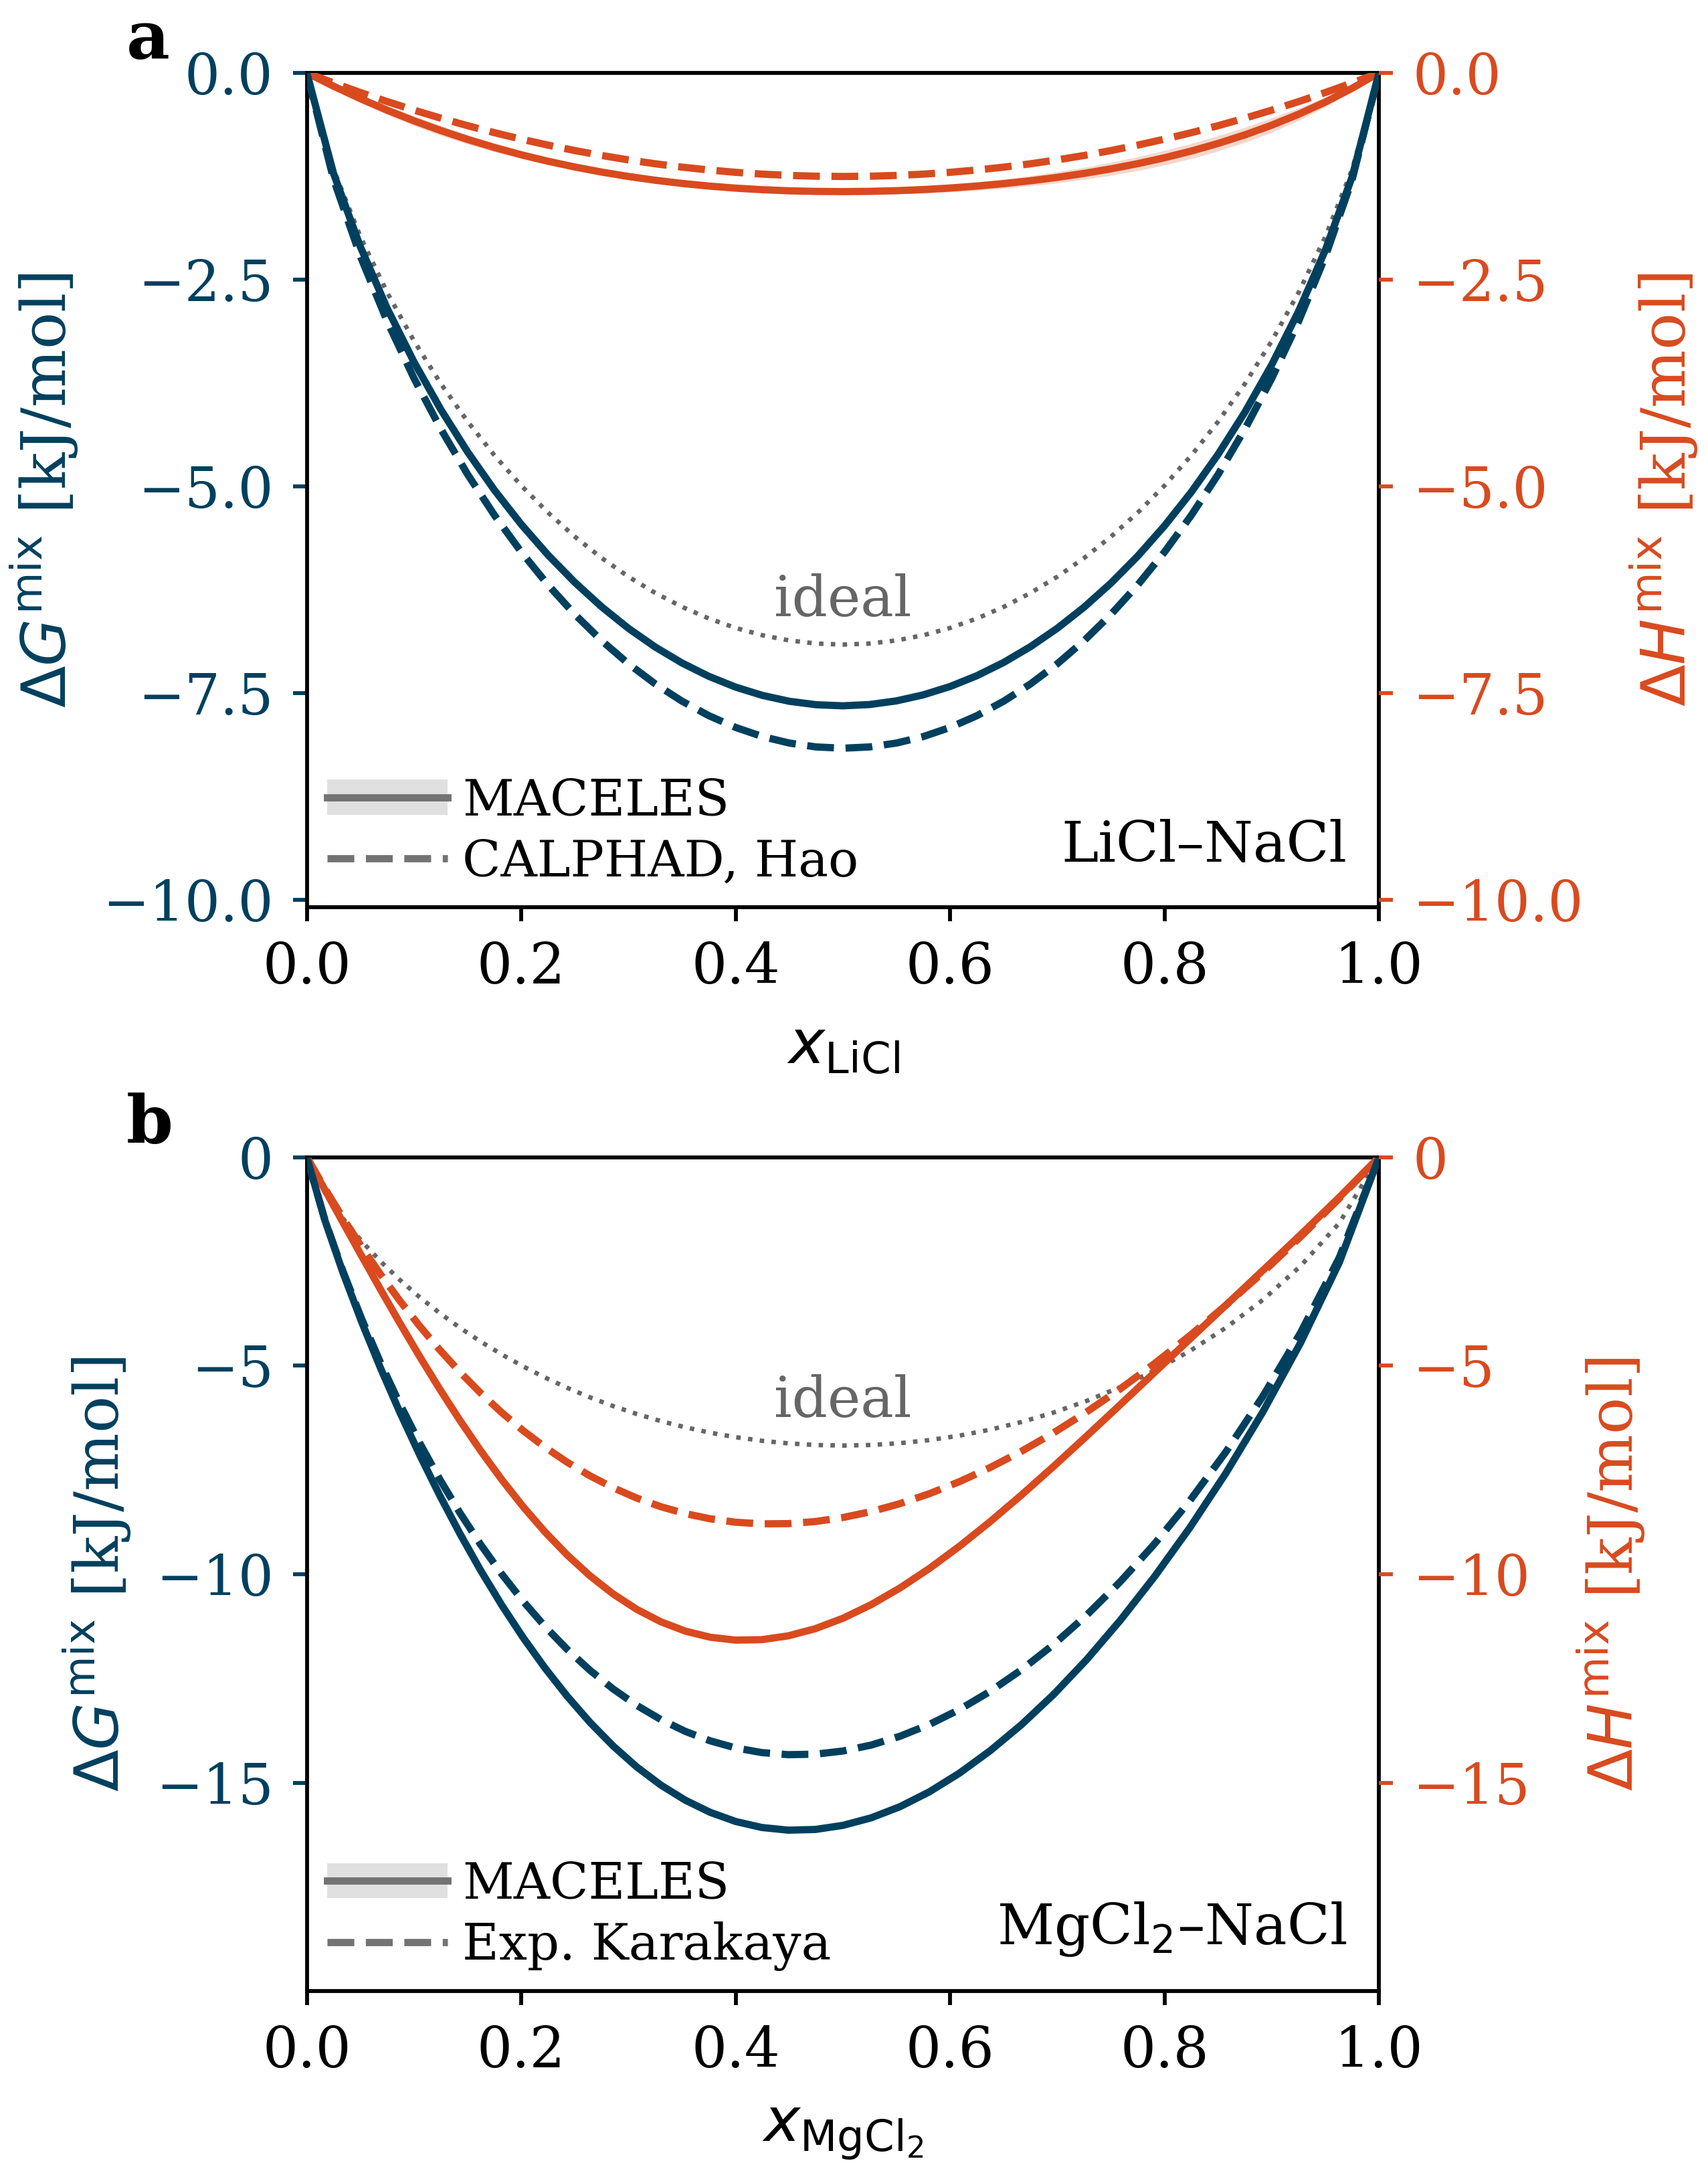

In [4]:
# NOT sharex, even though both abscissae run over [0, 1]: the quantity is x_MgCl2 in panel a and
# x_LiCl in panel b, so a single shared label would be wrong for one of them.
fig, axes = plt.subplots(2, 1, figsize=(FIG_W*0.95, 5.4))
# hspace clears panel a's x label; left holds the Gibbs y label plus the bold panel letter, and
# right holds the enthalpy y label on the opposite spine.
fig.subplots_adjust(left=0.16, right=0.84, top=0.97, bottom=0.085, hspace=0.30)

for ax, sysinfo in zip(axes, SYSTEMS):
    panel_gh(ax, sysinfo)

# 0.45 in: the letters sit at each axes' TOP while the y label is vertically centred, so
# they cannot collide however close in x the letters are placed.
panel_labels(axes, dx_in=0.45)
save(fig, "fig_gh_twopanel")
plt.show()

In [5]:
# Numerical summary: this work against every literature curve the system has.  Doubles as the
# check that the figure reproduces its parents and that the literature columns are read correctly.
# Keyed by role; the Exp rows take the system's own label, since the two panels cite different
# measurements.
ROLE_FMT = {"G_exp": "{exp} dG_mix", "H_exp": "{exp} dH_mix"}

for _ltr, sysinfo in zip("ab", SYSTEMS):
    df, lit = sysinfo["df"], sysinfo["lit_df"]
    x = df[sysinfo["xcol"]].to_numpy()
    g, sg = df["G_mix_kJ_mol"].to_numpy(), df["sem_G_kJ_mol"].to_numpy()
    h, sh = df["H_mix_kJ_mol"].to_numpy(), df["sem_H_kJ_mol"].to_numpy()
    gid = df["G_ideal_kJ_mol"].to_numpy()
    ig, ih = int(np.argmin(g)), int(np.argmin(h))
    k = int(np.argmin(np.abs(x - 0.5)))

    print(f'({_ltr}) {sysinfo["name"]}   [{UNIT_LABEL} per formula unit, bands {CONF_PC}]')
    print(f"     this work dG_mix  min {g[ig]:+.3f} +/- {sg[ig]:.3f} at x = {x[ig]:.3f}")
    print(f"     this work dH_mix  min {h[ih]:+.3f} +/- {sh[ih]:.3f} at x = {x[ih]:.3f}")
    print(f"     ideal             min {gid.min():+.3f} at x = {x[int(np.argmin(gid))]:.3f}")
    for _role, _col in sysinfo["lit_cols"].items():
        y = lit[_col].to_numpy()
        j = int(np.argmin(y))
        ours = g if _role == "G_exp" else h        # compare like with like
        _lab = ROLE_FMT[_role].format(exp=sysinfo["exp_label"])
        print(f"     {_lab}    min {y[j]:+.3f} at x = {x[j]:.3f}"
              f"   |  at x=0.5 {y[k]:+.3f} vs ours {ours[k]:+.3f}"
              f"  (diff {y[k] - ours[k]:+.3f})")
    _tds = h[k] - g[k]
    print(f"     at x = {x[k]:.3f}:  T*dS_mix = dH - dG = {_tds:+.3f}, "
          f"{abs(_tds / gid[k]):.2f}x the ideal entropy term\n")

(a) LiCl–NaCl   [kJ/mol per formula unit, bands 1 sigma]
     this work dG_mix  min -7.657 +/- 0.025 at x = 0.500
     this work dH_mix  min -1.437 +/- 0.035 at x = 0.500
     ideal             min -6.916 at x = 0.500
     CALPHAD, Hao dH_mix    min -1.254 at x = 0.500   |  at x=0.5 -1.254 vs ours -1.437  (diff +0.183)
     CALPHAD, Hao dG_mix    min -8.170 at x = 0.500   |  at x=0.5 -8.170 vs ours -7.657  (diff -0.513)
     at x = 0.500:  T*dS_mix = dH - dG = +6.220, 0.90x the ideal entropy term

(b) MgCl$_2$–NaCl   [kJ/mol per formula unit, bands 1 sigma]
     this work dG_mix  min -16.137 +/- 0.041 at x = 0.449
     this work dH_mix  min -11.581 +/- 0.036 at x = 0.400
     ideal             min -6.916 at x = 0.500
     Exp. Karakaya dH_mix    min -8.793 at x = 0.424   |  at x=0.5 -8.642 vs ours -11.057  (diff +2.415)
     Exp. Karakaya dG_mix    min -14.328 at x = 0.449   |  at x=0.5 -14.240 vs ours -16.023  (diff +1.783)
     at x = 0.500:  T*dS_mix = dH - dG = +4.965, 0.72x the id